In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# ==============================
# Paths (updated for you)
# ==============================
base_path = "/content/drive/MyDrive/age verification/data/common_voice/metadata"

train_path = f"{base_path}/train.tsv"
dev_path   = f"{base_path}/dev.tsv"
test_path  = f"{base_path}/test.tsv"
durations_path = f"{base_path}/clip_durations.tsv"

# ==============================
# Load files
# ==============================
train = pd.read_csv(train_path, sep='\t')
dev = pd.read_csv(dev_path, sep='\t')
test = pd.read_csv(test_path, sep='\t')
durations = pd.read_csv(durations_path, sep='\t')

# ==============================
# Prepare duration file
# ==============================
durations = durations.rename(columns={'clip': 'path'})
durations['duration_sec'] = durations['duration[ms]'] / 1000

# ==============================
# Merge
# ==============================
train = train.merge(durations[['path', 'duration_sec']], on='path', how='left')
dev = dev.merge(durations[['path', 'duration_sec']], on='path', how='left')
test = test.merge(durations[['path', 'duration_sec']], on='path', how='left')

# ==============================
# Combine all splits
# ==============================
all_data = pd.concat([train, dev, test], ignore_index=True)

# ==============================
# Save final file
# ==============================
output_path = f"{base_path}/metadata_all.tsv"
all_data.to_csv(output_path, sep='\t', index=False)

print("Done ✅ saved at:", output_path)

/tmp/ipykernel_4607/3190606610.py:16: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(train_path, sep='\t')


Done ✅ saved at: /content/drive/MyDrive/age verification/data/common_voice/metadata/metadata_all.tsv


In [ ]:
# -*- coding: utf-8 -*-
"""
Common Voice Speaker Inventory Builder

This script constructs file-level metadata and speaker-level inventory
for the Common Voice portion of the dataset construction protocol.

Current scope
-------------
This script is designed for the Common Voice speaker pool using the
final metadata file prepared earlier.

Main outputs
------------
1. File metadata:
   One row per available audio file.

2. Speaker inventory:
   One row per speaker, including:
   - dataset_source
   - speaker_id
   - source_age
   - mapped_age
   - gender
   - total_raw_duration_sec
   - num_files
   - role

Notes
-----
- This script operates before VAD-based preprocessing and segmentation.
- It uses raw file durations only.
- It is intended for inventory construction, not final dataset generation.
"""

from __future__ import annotations

import random
from pathlib import Path

import pandas as pd


# =========================================================
# Configuration
# =========================================================

CV_METADATA_PATH = Path(
    "/content/drive/MyDrive/age verification/data/common_voice/metadata/metadata_all.tsv"
)

FILE_METADATA_OUT = Path(
    "/content/drive/MyDrive/age verification/data/common_voice/metadata/cv_file_metadata.tsv"
)

SPEAKER_INVENTORY_OUT = Path(
    "/content/drive/MyDrive/age verification/data/common_voice/metadata/cv_speaker_inventory.tsv"
)

DATASET_SOURCE = "common_voice"
MIN_TOTAL_DURATION_SEC = 12.0
RANDOM_SEED = 42

VALID_GENDERS = ["male", "female", "male_masculine", "female_feminine"]

MINOR_AGES = {"teens"}
ADULT_AGES = {
    "twenties",
    "thirties",
    "fourties",
    "fifties",
    "sixties",
    "seventies",
    "eighties",
    "nineties",
}


# =========================================================
# Loading
# =========================================================
def load_common_voice_metadata(metadata_path: Path) -> pd.DataFrame:
    """
    Load the prepared Common Voice metadata file.
    """
    df = pd.read_csv(metadata_path, sep="\t")
    return df


# =========================================================
# Cleaning and Standardization
# =========================================================
def standardize_common_voice_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and standardize Common Voice metadata.

    Expected required columns
    -------------------------
    - client_id
    - path
    - age
    - gender
    - duration_sec
    """
    df = df.copy()

    required_cols = ["client_id", "path", "age", "gender", "duration_sec"]
    df = df.dropna(subset=required_cols).copy()

    df["client_id"] = df["client_id"].astype(str).str.strip()
    df["path"] = df["path"].astype(str).str.strip()
    df["age"] = df["age"].astype(str).str.strip().str.lower()
    df["gender"] = df["gender"].astype(str).str.strip().str.lower()

    df = df[
        (df["client_id"] != "") &
        (df["path"] != "") &
        (df["age"] != "") &
        (df["gender"] != "")
    ].copy()

    df = df[df["gender"].isin(VALID_GENDERS)].copy()

    gender_map = {
        "male": "m",
        "male_masculine": "m",
        "female": "f",
        "female_feminine": "f",
    }
    df["gender"] = df["gender"].map(gender_map)

    # Rename client_id -> speaker_id to unify with other datasets
    df = df.rename(columns={"client_id": "speaker_id"})

    # Add unified dataset field
    df["dataset_source"] = DATASET_SOURCE

    # Preserve original age label from source
    df["source_age"] = df["age"]

    # Map source age -> minor/adult
    def map_age(age_value: str) -> str | None:
        if age_value in MINOR_AGES:
            return "minor"
        if age_value in ADULT_AGES:
            return "adult"
        return None

    df["mapped_age"] = df["source_age"].apply(map_age)

    # Drop rows with unmapped age if any
    df = df.dropna(subset=["mapped_age"]).copy()

    return df


# =========================================================
# Output Builders
# =========================================================
def build_file_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construct file-level metadata for Common Voice.
    """
    return df[
        [
            "dataset_source",
            "speaker_id",
            "source_age",
            "mapped_age",
            "gender",
            "duration_sec",
            "path",
        ]
    ].copy()


def build_speaker_inventory(file_metadata_df: pd.DataFrame) -> pd.DataFrame:
    """
    Construct speaker-level inventory required by the dataset protocol.
    """
    speaker_inventory_df = (
        file_metadata_df
        .groupby("speaker_id", as_index=False)
        .agg(
            dataset_source=("dataset_source", "first"),
            source_age=("source_age", "first"),
            mapped_age=("mapped_age", "first"),
            gender=("gender", "first"),
            total_raw_duration_sec=("duration_sec", "sum"),
            num_files=("path", "count"),
        )
    )

    speaker_inventory_df["total_raw_duration_sec"] = (
        speaker_inventory_df["total_raw_duration_sec"].round(3)
    )

    return speaker_inventory_df[
        [
            "dataset_source",
            "speaker_id",
            "source_age",
            "mapped_age",
            "gender",
            "total_raw_duration_sec",
            "num_files",
        ]
    ].copy()


# =========================================================
# Inventory Role Assignment
# =========================================================
def assign_inventory_role(total_raw_duration_sec: float) -> str:
    """
    Assign a preliminary speaker role based on total raw duration.

    Rules
    -----
    < 12 sec   -> drop
    12-90 sec  -> real_candidates
    > 90 sec   -> randomly assign to spoof_targets or backup
    """
    if pd.isna(total_raw_duration_sec) or total_raw_duration_sec < 12:
        return "drop"
    if total_raw_duration_sec <= 90:
        return "real_candidates"

    return random.choice(["spoof_targets", "backup"])


def filter_inventory_by_duration(
    speaker_inventory_df: pd.DataFrame,
    min_total_duration_sec: float = MIN_TOTAL_DURATION_SEC,
) -> pd.DataFrame:
    """
    Remove speakers with insufficient total raw duration.
    """
    return speaker_inventory_df[
        speaker_inventory_df["total_raw_duration_sec"] >= min_total_duration_sec
    ].copy()


# =========================================================
# Main
# =========================================================
def main() -> None:
    # Fix randomness
    random.seed(RANDOM_SEED)

    print("\n" + "=" * 60)
    print("COMMON VOICE INVENTORY PIPELINE")
    print("=" * 60)

    print("[1/4] Loading prepared metadata...")
    df = load_common_voice_metadata(CV_METADATA_PATH)
    total_rows = len(df)

    print("[2/4] Cleaning and standardizing metadata...")
    df = standardize_common_voice_metadata(df)

    # Fix row order for reproducibility
    df = df.sort_values(by=["speaker_id", "path"]).reset_index(drop=True)
    retained_rows = len(df)

    print("[3/4] Building file metadata...")
    file_metadata_df = build_file_metadata(df)

    # Optional: keep file metadata order fixed too
    file_metadata_df = file_metadata_df.sort_values(
        by=["speaker_id", "path"]
    ).reset_index(drop=True)

    FILE_METADATA_OUT.parent.mkdir(parents=True, exist_ok=True)
    file_metadata_df.to_csv(FILE_METADATA_OUT, sep="\t", index=False)

    print("[4/4] Building speaker inventory...")
    speaker_inventory_df = build_speaker_inventory(file_metadata_df)

    # Fix speaker order for reproducibility
    speaker_inventory_df = speaker_inventory_df.sort_values(
        by=["speaker_id"]
    ).reset_index(drop=True)

    speaker_inventory_df["role"] = speaker_inventory_df[
        "total_raw_duration_sec"
    ].apply(assign_inventory_role)

    # Before filtering
    role_counts_before = speaker_inventory_df["role"].value_counts(dropna=False)
    role_counts_before.index.name = None

    # Filter inventory
    speaker_inventory_df = filter_inventory_by_duration(
        speaker_inventory_df=speaker_inventory_df,
        min_total_duration_sec=MIN_TOTAL_DURATION_SEC,
    )

    # Keep final output order fixed
    speaker_inventory_df = speaker_inventory_df.sort_values(
        by=["speaker_id"]
    ).reset_index(drop=True)

    SPEAKER_INVENTORY_OUT.parent.mkdir(parents=True, exist_ok=True)
    speaker_inventory_df.to_csv(SPEAKER_INVENTORY_OUT, sep="\t", index=False)

    gender_counts_after = speaker_inventory_df["gender"].value_counts(dropna=False)
    gender_counts_after.index.name = None

    mapped_age_counts_after = speaker_inventory_df["mapped_age"].value_counts(dropna=False)
    mapped_age_counts_after.index.name = None

    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"Total input rows            : {total_rows}")
    print(f"Rows retained after clean   : {retained_rows}")
    print(f"File metadata saved to      : {FILE_METADATA_OUT}")
    print(f"Speaker inventory saved to  : {SPEAKER_INVENTORY_OUT}")
    print(f"Random seed                 : {RANDOM_SEED}")

    print("\n" + "=" * 60)
    print("ROLE DISTRIBUTION")
    print("=" * 60)
    print(role_counts_before.to_string())

    print("\n" + "=" * 60)
    print("GENDER DISTRIBUTION")
    print("=" * 60)
    print(gender_counts_after.to_string())

    print("\n" + "=" * 60)
    print("MAPPED AGE DISTRIBUTION")
    print("=" * 60)
    print(mapped_age_counts_after.to_string())


if __name__ == "__main__":
    main()


COMMON VOICE INVENTORY PIPELINE
[1/4] Loading prepared metadata...


/tmp/ipykernel_4607/2669120284.py:86: DtypeWarning: Columns (4,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadata_path, sep="\t")


[2/4] Cleaning and standardizing metadata...
[3/4] Building file metadata...
[4/4] Building speaker inventory...

SUMMARY
Total input rows            : 1180272
Rows retained after clean   : 789920
File metadata saved to      : /content/drive/MyDrive/age verification/data/common_voice/metadata/cv_file_metadata.tsv
Speaker inventory saved to  : /content/drive/MyDrive/age verification/data/common_voice/metadata/cv_speaker_inventory.tsv
Random seed                 : 42

ROLE DISTRIBUTION
real_candidates    8305
backup             2647
drop               2608
spoof_targets      2581

GENDER DISTRIBUTION
m    10358
f     3175

MAPPED AGE DISTRIBUTION
adult    11813
minor     1720


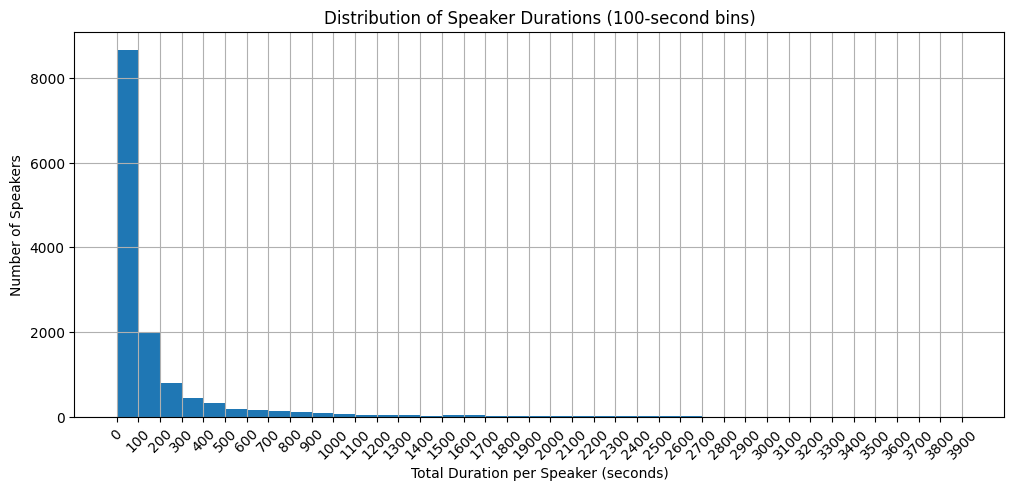

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

common_voice = "/content/drive/MyDrive/age verification/data/common_voice/metadata/cv_speaker_inventory.tsv"

df = pd.read_csv(common_voice, sep="\t")

df_filtered = df[df["total_raw_duration_sec"] < df["total_raw_duration_sec"].quantile(0.99)]

max_duration = df_filtered["total_raw_duration_sec"].max()
bins = np.arange(0, max_duration + 100, 100)

plt.figure(figsize=(12, 5))
df_filtered["total_raw_duration_sec"].hist(bins=bins)

plt.xlabel("Total Duration per Speaker (seconds)")
plt.ylabel("Number of Speakers")
plt.title("Distribution of Speaker Durations (100-second bins)")

plt.xticks(bins, rotation=45)
plt.grid(True)

plt.show()